# Import packages

In [27]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

# Load Data

In [28]:
# Set base path and data path and read event_info and feature_description
base_path = "wind_turbine_fault_detection\Wind_Farm_A"
data_path = os.path.join(base_path, "datasets")
event_info = pd.read_csv(os.path.join(base_path, "event_info.csv"), sep=';')
feature_description = pd.read_csv(os.path.join(base_path, "feature_description.csv"), sep=';')

In [29]:
event_info.head()

,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,11,68,anomaly,2023-07-28 13:20:00,52063,2023-08-11 13:10:00,54076,Transformer failure
1,21,22,anomaly,2023-08-12 09:50:00,51888,2023-08-19 10:00:00,52892,Hydraulic group
2,21,72,anomaly,2023-10-10 08:40:00,52497,2023-10-17 08:40:00,53505,Gearbox failure
3,0,73,anomaly,2023-06-10 11:40:00,52745,2023-06-17 11:40:00,53753,Hydraulic group
4,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure


In [30]:
event_info_filtered = event_info[event_info['asset'] == 0]
event_info_filtered.head()

,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
3,0,73,anomaly,2023-06-10 11:40:00,52745,2023-06-17 11:40:00,53753,Hydraulic group
4,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure
5,0,26,anomaly,2023-10-12 10:20:00,52261,2023-10-19 10:20:00,53269,Hydraulic group
14,0,24,normal,2023-04-27 15:00:00,52720,2023-05-11 11:20:00,54714,NaN
18,0,71,normal,2023-01-02 00:00:00,52439,2023-01-16 00:00:00,54455,NaN


In [31]:
feature_description.head()

,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
1,sensor_1,average,Wind absolute direction,�,True,False
2,sensor_2,average,Wind relative direction,�,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False


In [32]:
# Read data
files = ["0.csv","24.csv","26.csv","71.csv","73.csv"]

data_list = []
for f in files:
    df = pd.read_csv(os.path.join(data_path,f), sep=';')
    df["event_id"] = int(f.replace(".csv",""))
    data_list.append(df)

#Show columns
df.columns

Index(['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id',
       'sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg', 'wind_speed_3_avg',
       'wind_speed_4_avg', 'wind_speed_3_max', 'wind_speed_3_min',
       'wind_speed_3_std', 'sensor_5_avg', 'sensor_5_max', 'sensor_5_min',
       'sensor_5_std', 'sensor_6_avg', 'sensor_7_avg', 'sensor_8_avg',
       'sensor_9_avg', 'sensor_10_avg', 'sensor_11_avg', 'sensor_12_avg',
       'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg', 'sensor_16_avg',
       'sensor_17_avg', 'sensor_18_avg', 'sensor_18_max', 'sensor_18_min',
       'sensor_18_std', 'sensor_19_avg', 'sensor_20_avg', 'sensor_21_avg',
       'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg', 'sensor_25_avg',
       'sensor_26_avg', 'reactive_power_27_avg', 'reactive_power_27_max',
       'reactive_power_27_min', 'reactive_power_27_std',
       'reactive_power_28_avg', 'reactive_power_28_max',
       'reactive_power_28_min', 'reactive_power_28_std', 'power_29_avg',
      

In [33]:
#Concatenate data
raw_data = pd.concat(data_list)
#Convert to datetime and sort by time_stamp
raw_data["time_stamp"] = pd.to_datetime(raw_data["time_stamp"])
raw_data = raw_data.sort_values("time_stamp")
raw_data = raw_data.reset_index(drop=True)
print(raw_data.shape)
raw_data.head()

(272477, 87)


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg,event_id
0,2022-01-01 00:00:00,0,0,train,0,18.0,178.7,-18.6,4.1,4.4,...,-11991.0,0.0,18831.0,-11991.0,11.1,11.7,10.9,0.1,20.0,71
1,2022-01-01 00:10:00,0,1,train,0,18.0,191.8,-12.2,4.1,4.3,...,-14360.0,0.0,15865.0,-14360.0,11.1,11.3,10.9,0.1,20.0,71
2,2022-01-01 00:20:00,0,2,train,0,18.0,213.8,16.8,4.1,4.4,...,-15524.0,0.0,17244.0,-15524.0,11.1,11.3,10.9,0.1,20.0,71
3,2022-01-01 00:30:00,0,3,train,0,18.0,199.3,-4.6,4.4,4.6,...,-16444.0,0.0,22284.0,-16444.0,11.2,12.4,10.9,0.2,20.0,71
4,2022-01-01 00:40:00,0,4,train,0,18.0,199.9,-4.0,5.5,5.7,...,-16353.0,0.0,49587.0,-16353.0,11.4,12.1,10.9,0.3,20.0,71


In [34]:
# Flag the anomaly events in the raw_data
# status_type_id meanings:
#   0 → Normal Operation  (normal)
#   1 → Derated Operation (anomaly)
#   2 → Idling            (normal)
#   3 → Service           (anomaly)
#   4 → Downtime          (anomaly)
#   5 → Other             (anomaly)

ANOMALY_STATUSES = [1, 3, 4, 5]

raw_data['fault_flag'] = raw_data['status_type_id'].isin(ANOMALY_STATUSES).astype(int)

print(f"Total timesteps        : {len(raw_data):,}")
print(f"Anomaly (fault_flag=1) : {raw_data['fault_flag'].sum():,}")
print(f"Normal  (fault_flag=0) : {(raw_data['fault_flag'] == 0).sum():,}")
raw_data[['time_stamp', 'status_type_id', 'fault_flag']].head(20)

Total timesteps        : 272,477
Anomaly (fault_flag=1) : 35,668
Normal  (fault_flag=0) : 236,809


,time_stamp,status_type_id,fault_flag
0,2022-01-01 00:00:00,0,0
1,2022-01-01 00:10:00,0,0
2,2022-01-01 00:20:00,0,0
3,2022-01-01 00:30:00,0,0
4,2022-01-01 00:40:00,0,0
5,2022-01-01 00:50:00,0,0
6,2022-01-01 01:00:00,0,0
7,2022-01-01 01:10:00,0,0
8,2022-01-01 01:20:00,0,0
9,2022-01-01 01:30:00,0,0


In [35]:
# Also flag anomaly event windows from event_info_filtered (asset_id = 0)
# fault_flag from the previous cell (status_type_id-based) is preserved;
# we only ADD new 1s on top — never reset existing flags.
# We match on event_id and check whether each timestamp falls within [event_start, event_end]

# Ensure event_start / event_end are datetime
event_info_filtered = event_info_filtered.copy()
event_info_filtered['event_start'] = pd.to_datetime(event_info_filtered['event_start'])
event_info_filtered['event_end']   = pd.to_datetime(event_info_filtered['event_end'])

# For every anomaly event, flag the matching timestamps
anomaly_events = event_info_filtered[event_info_filtered['event_label'] == 'anomaly']

for _, row in anomaly_events.iterrows():
    mask = (
        (raw_data['event_id']   == row['event_id']) &
        (raw_data['time_stamp'] >= row['event_start']) &
        (raw_data['time_stamp'] <= row['event_end'])
    )
    raw_data.loc[mask, 'fault_flag'] = 1

print(f"Total timesteps      : {len(raw_data):,}")
print(f"Anomaly  (fault_flag=1): {raw_data['fault_flag'].sum():,}")
print(f"Normal   (fault_flag=0): {(raw_data['fault_flag'] == 0).sum():,}")
raw_data[['time_stamp', 'event_id', 'fault_flag']].head(20)


Total timesteps      : 272,477
Anomaly  (fault_flag=1): 35,668
Normal   (fault_flag=0): 236,809


,time_stamp,event_id,fault_flag
0,2022-01-01 00:00:00,71,0
1,2022-01-01 00:10:00,71,0
2,2022-01-01 00:20:00,71,0
3,2022-01-01 00:30:00,71,0
4,2022-01-01 00:40:00,71,0
5,2022-01-01 00:50:00,71,0
6,2022-01-01 01:00:00,71,0
7,2022-01-01 01:10:00,71,0
8,2022-01-01 01:20:00,71,0
9,2022-01-01 01:30:00,71,0


# Decoding Features

In [37]:
# Clean the feature description file
df_feature_description = pd.read_csv(os.path.join(base_path, "feature_description.csv"), sep=';').copy()
 
for i in range(len(df_feature_description['unit'])):
    if pd.isna(df_feature_description.loc[i,'unit']):
        df_feature_description.loc[i,'unit'] = '-'
    else:
        if '�' in df_feature_description.loc[i,'unit']:
            if df_feature_description.loc[i,'is_angle']:
                df_feature_description.loc[i,'unit'] = 'deg'
            elif ('Temperature'or'temperature' in df_feature_description.loc[i,'unit']) and ('C' in df_feature_description.loc[i,'unit']):
                df_feature_description.loc[i,'unit'] = 'Celsius'
 
df_feature_description.head()

,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,Celsius,False,False
1,sensor_1,average,Wind absolute direction,deg,True,False
2,sensor_2,average,Wind relative direction,deg,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False


In [40]:
# Decoding Features in raw_data
# Build a rename map: {sensor_name}_{suffix} → {description}_{suffix}
# statistics_type values and their column suffixes:
#   average  → _avg  |  maximum → _max  |  minimum → _min  |  std_dev → _std

STAT_SUFFIX = {
    'average': '_avg',
    'maximum': '_max',
    'minimum': '_min',
    'std_dev': '_std',
}

rename_map = {}
for _, row in df_feature_description.iterrows():
    sensor = row['sensor_name']
    desc   = row['description']
    stats  = [s.strip() for s in str(row['statistics_type']).split(',')]
    for stat in stats:
        suffix  = STAT_SUFFIX.get(stat, f'_{stat}')
        old_col = f"{sensor}{suffix}"
        new_col = f"{desc}{suffix}"
        rename_map[old_col] = new_col

raw_data = raw_data.rename(columns=rename_map)

print(f"Renamed {len(rename_map)} sensor columns.")
print("\nSample mappings (old → new):")
for old, new in list(rename_map.items())[:8]:
    print(f"  {old:35s} → {new}")
raw_data.head()

processed_data = raw_data.copy()

Renamed 81 sensor columns.

Sample mappings (old → new):
  sensor_0_avg                        → Ambient temperature_avg
  sensor_1_avg                        → Wind absolute direction_avg
  sensor_2_avg                        → Wind relative direction_avg
  wind_speed_3_max                    → Windspeed_max
  wind_speed_3_min                    → Windspeed_min
  wind_speed_3_avg                    → Windspeed_avg
  wind_speed_3_std                    → Windspeed_std
  wind_speed_4_avg                    → Estimated windspeed_avg


In [41]:
processed_data.columns

# Plot Sensor Timeseries with Event Overlay

Index(['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id',
       'Ambient temperature_avg', 'Wind absolute direction_avg',
       'Wind relative direction_avg', 'Windspeed_avg',
       'Estimated windspeed_avg', 'Windspeed_max', 'Windspeed_min',
       'Windspeed_std', 'Pitch angle_avg', 'Pitch angle_max',
       'Pitch angle_min', 'Pitch angle_std',
       'Temperature in the hub controller_avg',
       'Temperature in the top nacelle controller_avg',
       'Temperature in the choke coils on the VCS-section_avg',
       'Temperature on the VCP-board_avg',
       'Temperature in the VCS cooling water_avg',
       'Temperature in gearbox bearing on high speed shaft_avg',
       'Temperature oil in gearbox_avg',
       'Temperature in generator bearing 2 (Drive End)_avg',
       'Temperature in generator bearing 1 (Non-Drive End)_avg',
       'Temperature inside generator in stator windings phase 1_avg',
       'Temperature inside generator in stator windings phase 2_avg',


# Plot Sensor Timeseries with Event Overlay
- Create a function that, given a sensor name (e.g., `sensor_1_avg`) and a time window, plots the sensor values.
- On the same plot, highlight the periods where `fault_flag == 1` (anomaly events) with a shaded background.
- This is essential for exploratory data analysis.

⚠️  Multiple event_ids share this time window: [np.int64(0), np.int64(24), np.int64(71), np.int64(73)]
   Auto-selecting event_id=73. Pass event_id=<n> to choose another.


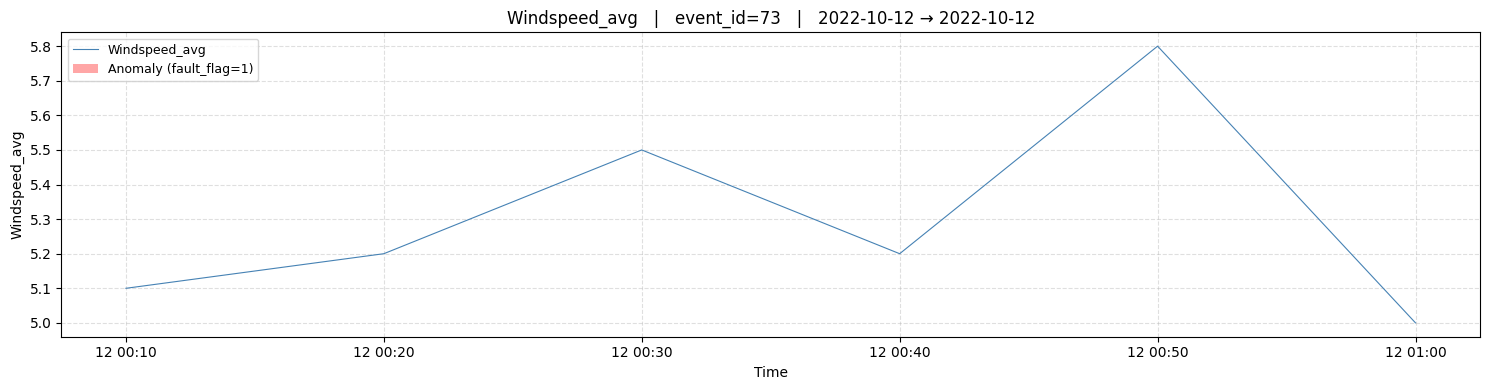

In [48]:
def plot_sensor_timeseries(sensor_name, time_wind, event_id=None, data=None):
    """
    Plot a sensor time series with anomaly windows shaded in red.

    Parameters
    ----------
    sensor_name : str
        Column name to plot (e.g. 'Windspeed_avg').
    time_wind   : tuple of (str | datetime-like, str | datetime-like)
        (start, end) of the time window to display.
    event_id    : int, optional
        Filter to a single event file to avoid zigzag artefacts caused by
        multiple events sharing the same (anonymised) timestamps.
        If None, all event_ids in the window are detected and the first is
        used automatically with a warning.
    data        : pd.DataFrame, optional
        Source dataframe. Defaults to raw_data.
    """
    if data is None:
        data = raw_data

    start = pd.to_datetime(time_wind[0])
    end   = pd.to_datetime(time_wind[1])

    # --- Slice to time window ---
    mask = (data['time_stamp'] >= start) & (data['time_stamp'] <= end)
    df   = data.loc[mask].copy()

    if df.empty:
        print(f"No data found in the window [{start}  →  {end}].")
        return

    # --- Guard against multiple overlapping events (causes zigzag lines) ---
    events_in_window = df['event_id'].unique()
    if event_id is None:
        if len(events_in_window) > 1:
            print(f"⚠️  Multiple event_ids share this time window: {sorted(events_in_window)}")
            print(f"   Auto-selecting event_id={events_in_window[0]}. "
                  f"Pass event_id=<n> to choose another.")
        event_id = events_in_window[0]

    df = df[df['event_id'] == event_id].copy()

    if df.empty:
        print(f"No data for event_id={event_id} in the selected window.")
        return

    if sensor_name not in df.columns:
        raise ValueError(
            f"'{sensor_name}' not found.\n"
            f"Available sensor columns: "
            f"{[c for c in df.columns if c not in ['time_stamp','asset_id','id','event_id','train_test','status_type_id','fault_flag']]}"
        )

    fig, ax = plt.subplots(figsize=(15, 4))

    # --- Sensor line ---
    ax.plot(df['time_stamp'], df[sensor_name],
            color='steelblue', linewidth=0.8, label=sensor_name)

    # --- Shade contiguous fault_flag == 1 blocks ---
    fault_ts = df['time_stamp'].values
    fault_fl = df['fault_flag'].values

    in_fault    = False
    fault_start = None
    for t, f in zip(fault_ts, fault_fl):
        if f == 1 and not in_fault:
            fault_start = t
            in_fault    = True
        elif f == 0 and in_fault:
            ax.axvspan(fault_start, t, color='red', alpha=0.20, lw=0)
            in_fault = False
    if in_fault:                              # close open block at series end
        ax.axvspan(fault_start, fault_ts[-1], color='red', alpha=0.20, lw=0)

    # --- Legend ---
    from matplotlib.patches import Patch
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Patch(facecolor='red', alpha=0.35, label='Anomaly (fault_flag=1)'))
    ax.legend(handles=handles, fontsize=9, loc='upper left')

    ax.set_title(f'{sensor_name}   |   event_id={event_id}   |   {str(start.date())} → {str(end.date())}', fontsize=12)
    ax.set_xlabel('Time')
    ax.set_ylabel(sensor_name)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_sensor_timeseries('Windspeed_avg', ('2022-10-12 00:00:01', '2022-10-12 01:00:00'))

# EDA

# Define Metrics

# Train an Unsupervised Anomaly Detector

# Alarm Generation with Persistence Filter

# Plot Results